# Parameter estimation for protein sector parameters

This notebook was used to estimate the parameters for the translational protein sector as used in the revised proteome allocation model. This notebook has been created to establish the parameters for Cornyebacterium glutanicum ATCC 13032. Experimental data was obtained from [Matamouros et al (2023)](https://www.nature.com/articles/s41467-023-41176-y#data-availability) Supplementary Data 9.

The unused enzyme sector (code at the end of this notebook) was created using the maximal growth rate of the EVO5 strain from [Graf et al. (2019)](https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2019.01648/full), as reported in [Matamouros et al (2023)](https://www.nature.com/articles/s41467-023-41176-y#data-availability). The amount of unused enzymes at zero growth was assumed to be similar to the fraction in *E. coli*.

### Author: Samira L. van den Bogaard
## Setting up the notebook environment¶

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cobra.io import read_sbml_model
import datetime

if os.path.split(os.getcwd())[1] == 'i1_preprocessing':
    os.chdir('../..')
    

from PAModelpy import TransEnzymeSector, PAModel, Config
from Modules.utils.sector_config_functions import (perform_linear_regression,
                                                                        reset_translational_sector,
                                                                        plot_translational_protein_vs_mu,
                                                                        get_model_simulations_vs_sector,
                                                  )
from Modules.utils.pamparametrizer_setup import save_sector_information_to_excel

Loading PAModelpy modules version 0.0.5.1
Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-03


In [2]:
DATA_FILE_PATH = os.path.join('Data', 'Cglutanicum_phenotypes', 
                              'cglutanicum_proteomics.xlsx')

MODEL_FILE_PATH = os.path.join('Models', 'iCGB21FR_annotated_copyable.xml')
RESULT_FIG_PATH = os.path.join('Results', '1_preprocessing',
                               'figures', 'SuppFig_translational_sector_cglutanicum.png')
#output file path
#only define this one if you are updating the current parameters
PAM_DATA_FILE_PATH_parameters = os.path.join('Results', 
                                '1_preprocessing', 
                                f'proteinAllocationModel_iCGB21FR_EnzymaticData_250227.xlsx')

MEASURED_PROTEIN_FRACTION = 1
# MEASURED_PROTEIN_FRACTION = 0.55*0.55#0.55 * 0.55 #measured proteome vs g_p/gcdw in Ecoli

GLC_UPTAKE_RXN_ID = 'EX_glc__D_e'
BIOMASS_RXN_ID = 'Growth'
MW_GLC = 180.15588 #g/mol
PRT_BMS_FRACTION = 0.56 #g_p/g_CDW (assumption)

config = Config()
config.reset()
config.BIOMASS_REACTION = 'Growth'

#Parameters for unused enzyme sector determination
BIOMASS_RXN_ID = 'Growth'
MAX_GROWTH_ALE = 0.94#1/h; EVO5 strain from Graf et al 2019, growth rate obtained from Matamouros et al (2023)
UNUSED_PROTEIN_INTERCEPT = 0.37 #g_unusedprotein/g_protein; 37% (Bruggeman et al (2020)) of all the proteins which can be measured in E.coli
METABOLIC_PROTEIN_FRACTION = 0.56*0.5 #g_p/g_CDW

## Get the proteomics data 
The units of the ribosomal protein fraction are in g_ribosomes/g_protein. For the translational protein sector this has to be converted to g_ribosomes/g_CDW.

In [3]:
#get the validation data
df_proteomics = pd.read_excel(DATA_FILE_PATH, sheet_name = 'ribosome_fraction')
#filter out the stress conditions
df_proteomics

,Medium,growth_rate,growth_rate_error,ribosomal_protein_fraction,ribosomal_protein_fraction_error
0,BHI+CGXII+GLU+CAA,0.94,0.08,0.53,0.06
1,BHI+CGXII+GLU,0.77,0.07,0.43,0.05
2,BHI+GLU,0.61,0.02,0.23,0.03
3,CGXII+GLU,0.47,0.03,0.18,0.05
4,CGXII+ACE,0.40,0.01,0.15,0.02
5,CGXII+PYR,0.29,0.01,0.14,0.02
6,CGXII+EtOH+CAA,0.24,0.05,0.14,0.04
7,CGXII+LAC,0.27,0.07,0.12,0.02
8,CGXII+EtOH,0.12,0.01,0.11,0.02
9,CGXII+Glutamate,0.07,0.02,0.11,0.02


Text(0, 0.5, 'ribosomal fraction [$g_{ribosome}/g_{protein}$]')

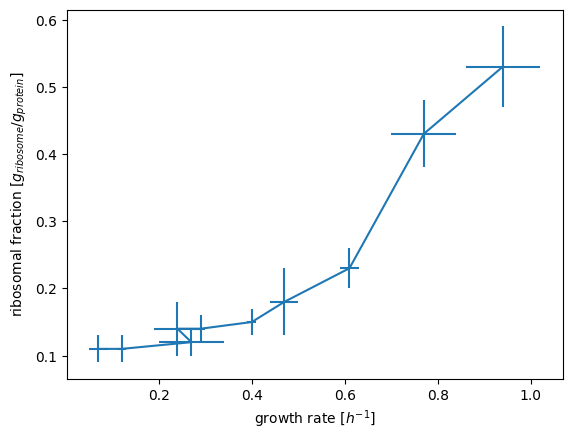

In [4]:
plt.errorbar(x = df_proteomics.growth_rate,
             y = df_proteomics.ribosomal_protein_fraction, 
             xerr = df_proteomics.growth_rate_error, 
             yerr = df_proteomics.ribosomal_protein_fraction_error
            )
plt.xlabel(r'growth rate [$h^{-1}$]')
plt.ylabel(r'ribosomal fraction [$g_{ribosome}/g_{protein}$]')

## Get growth rate vs ribosomal protein relation
Only make use of the linear relation in the lower growth rate regime (<0.4, as described by [Matamouros et al (2023)](https://www.nature.com/articles/s41467-023-41176-y#data-availability))

In [5]:
#get the relation with growth rate
slope, intercept = perform_linear_regression(x=df_proteomics['growth_rate'][df_proteomics['growth_rate']<0.4], 
                                             y=df_proteomics['ribosomal_protein_fraction'][df_proteomics['growth_rate']<0.4]*PRT_BMS_FRACTION)

print('Translational sector vs growth rate using data from  Matamouros et al (2023): \n Intercept: ',intercept, 'g/g_cdw')
print(' Slope: ',slope, 'g/g_cdw/h')

Translational sector vs growth rate using data from  Matamouros et al (2023): 
 Intercept:  0.055565364308342136 g/g_cdw
 Slope:  0.07007391763463569 g/g_cdw/h


## Use the mu vs translational protein relationship to perform simulations with the PAM model
The predicted glucose uptake rates can be used to derive the relationship between glucose uptake and translational protein.

In [6]:
#set up model without total protein constraint to just model the linear relation between
id_list_tps = [BIOMASS_RXN_ID]
tps_0 = [intercept]  # g/gDW
tps_mu = [slope]  # g h/gDW 
molmass_tps = [405903.94]  # g/mol

# translational protein sector
translation_enzyme_sector = TransEnzymeSector(
            id_list=id_list_tps,
            tps_0=tps_0,
            tps_mu=tps_mu,
            mol_mass=molmass_tps,
        )

model = read_sbml_model(MODEL_FILE_PATH)
pamodel = PAModel(id_or_model = model,
                  p_tot=False, 
                  translational_sector = translation_enzyme_sector,
                  configuration = config,
                  sensitivity = False) # sensitivity disabled to speed things up
#get parameters
translational_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')
tps_molmass = translational_sector.mol_mass[0]

#adjust relation in model
trans_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')

#adjust the translational protein sector
pamodel.change_sector_parameters(trans_sector, slope*MEASURED_PROTEIN_FRACTION,
                                 intercept*MEASURED_PROTEIN_FRACTION, lin_rxn_id = BIOMASS_RXN_ID)

Setting up the proteome allocation model iCBG21FR

Total condition-dependent protein constraint is not added 

Add the following protein sector: TranslationalProteinSector

Done with setting up the proteome allocation model iCBG21FR



In [7]:
#run the model
substrate_range = np.arange(-20,1,1)

#we shouldn't correct for measured total protein here, as we are comparing it to the measured data
simulation_results_bms = get_model_simulations_vs_sector(pamodel, GLC_UPTAKE_RXN_ID, BIOMASS_RXN_ID,
                                           substrate_range, intercept,slope) 


Running simulations with  -20 mmol/g_cdw/h of substrate going into the system
Running simulations with  -19 mmol/g_cdw/h of substrate going into the system
Running simulations with  -18 mmol/g_cdw/h of substrate going into the system
Running simulations with  -17 mmol/g_cdw/h of substrate going into the system
Running simulations with  -16 mmol/g_cdw/h of substrate going into the system
Running simulations with  -15 mmol/g_cdw/h of substrate going into the system
Running simulations with  -14 mmol/g_cdw/h of substrate going into the system
Running simulations with  -13 mmol/g_cdw/h of substrate going into the system
Running simulations with  -12 mmol/g_cdw/h of substrate going into the system
Running simulations with  -11 mmol/g_cdw/h of substrate going into the system
Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into

In [8]:
#derive the relation to glucose uptake rate
#results are in g_transprot/g_prot and need to be converted to g/gcdw (glucose uptake should stay in mmol for compatibility with model)
slope_glc, intercept_glc = perform_linear_regression(
    x=simulation_results_bms[GLC_UPTAKE_RXN_ID], y=simulation_results_bms['translational_protein'])

print('Translational sector vs glucose uptake using data from Schmidt et al (2016): \n Intercept: ',intercept_glc *MEASURED_PROTEIN_FRACTION, ' g/g_cdw')
print('Slope: ',slope_glc*MEASURED_PROTEIN_FRACTION, ' g/mmol_glucose/h')


Translational sector vs glucose uptake using data from Schmidt et al (2016): 
 Intercept:  0.07391547026160278  g/g_cdw
Slope:  -0.002086417280614491  g/mmol_glucose/h


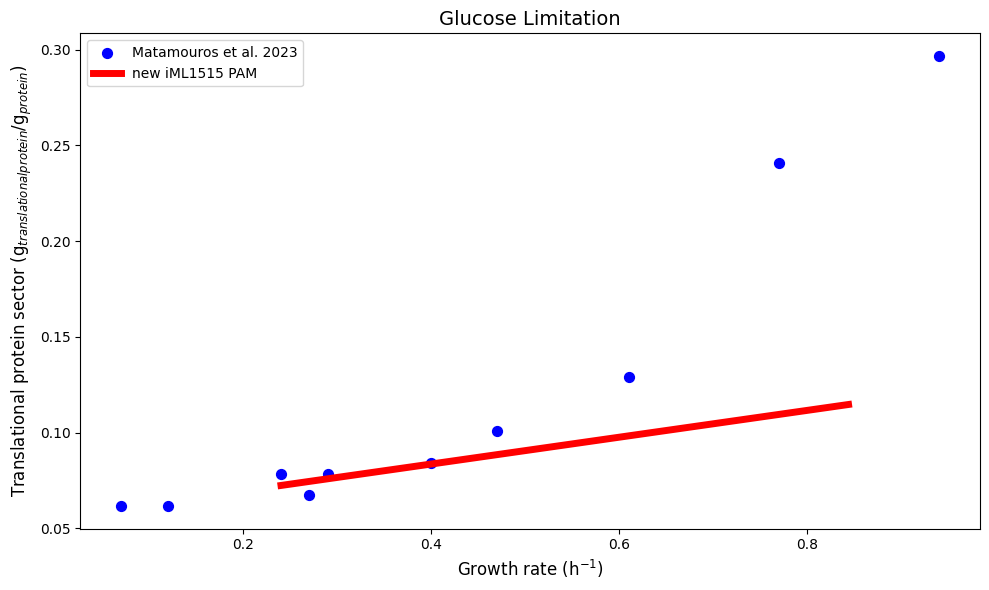

In [9]:
df_proteomics_to_plot = df_proteomics.rename({'growth_rate': 'Experimental Growth rate',
                                              'ribosomal_protein_fraction': 'Translation, ribosomal structure and biogenesis'
                                             }, axis = 1)
df_proteomics_to_plot['Translation, ribosomal structure and biogenesis'] = df_proteomics_to_plot['Translation, ribosomal structure and biogenesis']*100

plot_translational_protein_vs_mu(df_proteomics_to_plot, simulation_results_bms, 
                                 protein_fraction = 1, 
                                 measured_protein_fraction=PRT_BMS_FRACTION,
                                 configuration = config,
                                 literature_label = 'Matamouros et al. 2023',
                                 oxygen_results = None)

## Save the new model parameters

In [10]:
#save to excel
save_sector_information_to_excel(
    param_vs_lin_rxn={
        'slope': slope_glc*MEASURED_PROTEIN_FRACTION,
        'intercept': intercept_glc*MEASURED_PROTEIN_FRACTION
    },
    param_vs_growth={
        'slope': slope*MEASURED_PROTEIN_FRACTION,
        'intercept': intercept*MEASURED_PROTEIN_FRACTION
    },
    biomass_rxn=BIOMASS_RXN_ID,
    lin_rxn_id='EX_glc__D_e',
    sector_id='Translational',
    pam_data_file=PAM_DATA_FILE_PATH_parameters,
    model_name = 'iCGB21FR')

Results/1_preprocessing/proteinAllocationModel_iCGB21FR_EnzymaticData_250910.xlsx
         Parameter        Value  Value_for_growth          Unit  \
0          id_list  EX_glc__D_e            Growth           NaN   
1            tps_0     0.073915          0.055565        g/gcdw   
2           tps_mu    -0.002086          0.070074  g/mmol_glc/h   
3         mol_mass          NaN               NaN         g/mol   
4  substrate_range          NaN  [-4, -3, -2, -1]    mmol/gDW/h   

                                         Description  
0                          Substrate uptake reaction  
1  Protein concentration allocated to translation...  
2  Increase of protein allocated to translational...  
3        Molar mass of a fictional enzyme (ribosome)  
4  Range of values of susbstrate uptake which are...  


## Unused protein sector determination
We add dummy data for the relation to glucose, as this will be determined in the PAMparametrizer

In [11]:
# compute relation between growth and unused sector
ups_mu = -UNUSED_PROTEIN_INTERCEPT*METABOLIC_PROTEIN_FRACTION/MAX_GROWTH_ALE
ups_0 = UNUSED_PROTEIN_INTERCEPT*METABOLIC_PROTEIN_FRACTION

#save to excel
save_sector_information_to_excel(
    param_vs_lin_rxn={
        'slope': -ups_mu,
        'intercept': ups_0
    },
    param_vs_growth={
        'slope': ups_mu,
        'intercept': ups_0
    },
    biomass_rxn=BIOMASS_RXN_ID,
    lin_rxn_id='EX_glc__D_e',
    sector_id='UnusedEnzyme',
    pam_data_file=PAM_DATA_FILE_PATH_parameters,
    model_name = 'iCGB21FR')

Results/1_preprocessing/proteinAllocationModel_iCGB21FR_EnzymaticData_250910.xlsx
         Parameter        Value  Value_for_growth        Unit  \
0          id_list  EX_glc__D_e            Growth         NaN   
1           ups_mu     0.110213         -0.110213   g/g_CDW/h   
2            ups_0       0.1036            0.1036     g/g_CDW   
3         mol_mass          NaN               NaN       g/mol   
4  substrate_range          NaN  [-4, -3, -2, -1]  mmol/gDW/h   

                                         Description  
0  biomass formation reaction ID (representing gr...  
1  slope of relation between growth rate and prot...  
2  Protein concentration allocated to excess enzy...  
3                   Molar mass of a fictional enzyme  
4  Range of values of susbstrate uptake which are...  
